In [3]:
import os
import sys
path = os.getcwd()
while True:
    if 'utils.py' in os.listdir(path):
        if path not in sys.path:
            sys.path.append(path)
        break
    new_path = os.path.dirname(path)
    if new_path == path:
        upload_utils = files.upload()
        break
    path = new_path

import utils

Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.2_3B_Instruct/Results/checkpoint_scitail_Llama_3.2_3B_Instruct_full_zero_shot.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.2_3B_Instruct/Results/checkpoint_scitail_Llama_3.2_3B_Instruct_full_few_shot_1_examples_entails.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.2_3B_Instruct/Results/checkpoint_scitail_Llama_3.2_3B_Instruct_full_few_shot_1_examples_neutral.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.2_3B_Instruct/Results/checkpoint_scitail_Llama_3.2_3B_Instruct_full_few_shot_2_examples.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.2_3B_Instruct/Results/checkpoint_scitail_Ll

/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.2_3B_Instruct/Results/checkpoint_scitail_Llama_3.2_3B_Instruct_full_few_shot_10_examples.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.2_3B_Instruct/Results/checkpoint_scitail_Llama_3.2_3B_Instruct_full_few_shot_15_examples.pt
Checkpoint found.


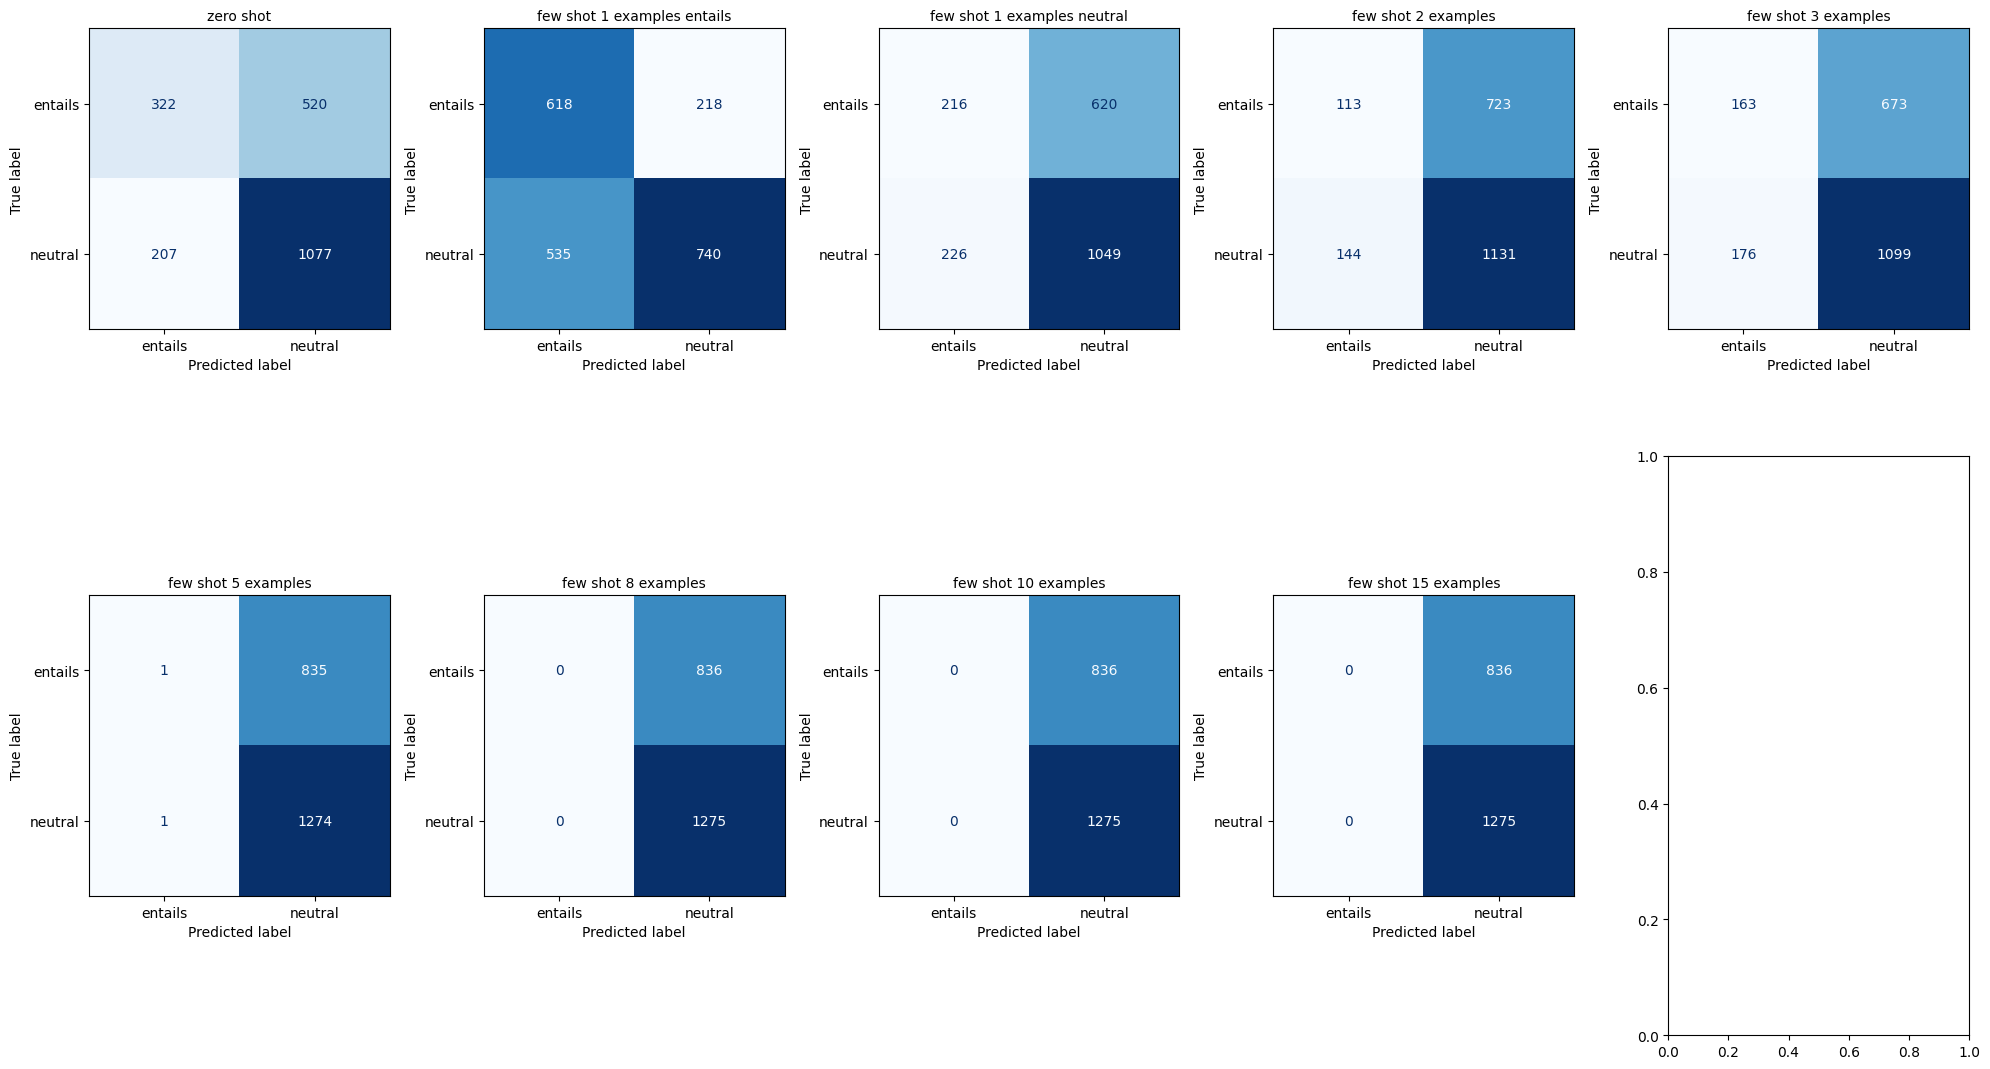

In [8]:
import matplotlib.pyplot as plt

training_modes = [
    'zero shot',
    'few shot 1 examples entails',
    'few shot 1 examples neutral',
    'few shot 2 examples',
    'few shot 3 examples',
    'few shot 5 examples',
    'few shot 8 examples',
    'few shot 10 examples',
    'few shot 15 examples'    
]

fig, axes = plt.subplots(2, 5, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

for idx, mode in enumerate(training_modes):
    global_params = {
            'dataset_type': 'scitail',
            'quantization': 'full',
            'training_mode': mode,
            'model_id': 'meta-llama/Llama-3.2-3B-Instruct'}
   
    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
labels = [
    "0 examples",
    "1 example (entails)",
    "1 example (neutral)",
    "2 examples",
    "3 examples",
    "5 examples",
    "8 examples",
    "10 examples",
    "15 examples"
]

metrics_df = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
     "F1": f1s,
     "MCC": mccs,
     "Kappa": kappas},
     index= labels
)
metrics_df

,Accuracy,Precision,Recalls,F1,MCC,Kappa
0 examples,0.6580,0.6415,0.6106,0.6087,0.2502,0.2363
1 example (entails),0.6433,0.6542,0.6598,0.6421,0.3140,0.3000
1 example (neutral),0.5992,0.5586,0.5406,0.5253,0.0975,0.0883
2 examples,0.5893,0.5249,0.5111,0.4648,0.0332,0.0252
3 examples,0.5978,0.5505,0.5285,0.4994,0.0758,0.0634
5 examples,0.6040,0.5520,0.5002,0.3777,0.0065,0.0005
8 examples,0.6040,0.3020,0.5000,0.3766,0.0000,0.0000
10 examples,0.6040,0.3020,0.5000,0.3766,0.0000,0.0000
15 examples,0.6040,0.3020,0.5000,0.3766,0.0000,0.0000


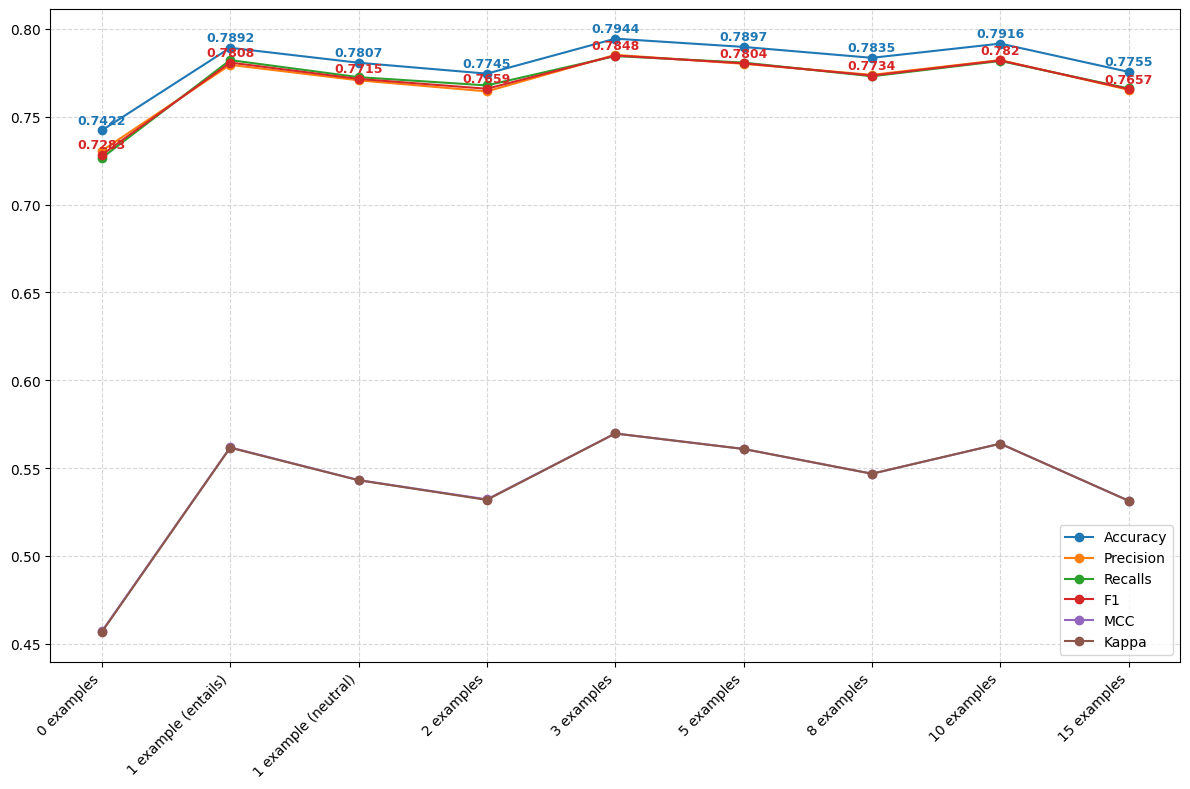

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

# plot all metrics
metrics_df.plot(kind='line', ax=ax, marker='o')

# set custom x-axis labels
ax.set_xticks(range(len(metrics_df.index)))
ax.set_xticklabels(metrics_df.index, rotation=45, ha='right')

# show grid
ax.grid(True, linestyle='--', alpha=0.5)

# annotate only Accuracy and F1
for metric in ["Accuracy", "F1"]:
    for x, y in enumerate(metrics_df[metric]):
        ax.text(x, y + 0.002, str(y), ha='center', va='bottom', fontsize=9, fontweight='bold', color=ax.get_lines()[list(metrics_df.columns).index(metric)].get_color())

plt.tight_layout()
plt.show()

Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.2_3B_Instruct/Results/checkpoint_scitail_Llama_3.2_3B_Instruct_full_zero_shot_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.2_3B_Instruct/Results/checkpoint_scitail_Llama_3.2_3B_Instruct_full_few_shot_1_examples_neutral_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.2_3B_Instruct/Results/checkpoint_scitail_Llama_3.2_3B_Instruct_full_few_shot_1_examples_entails_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Scitail_Llama_3.2_3B_Instruct/Results/checkpoint_scitail_Llama_3.2_3B_Instruct_full_few_shot_2_examples_chat_template.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/Scitail_Notebooks/Sci

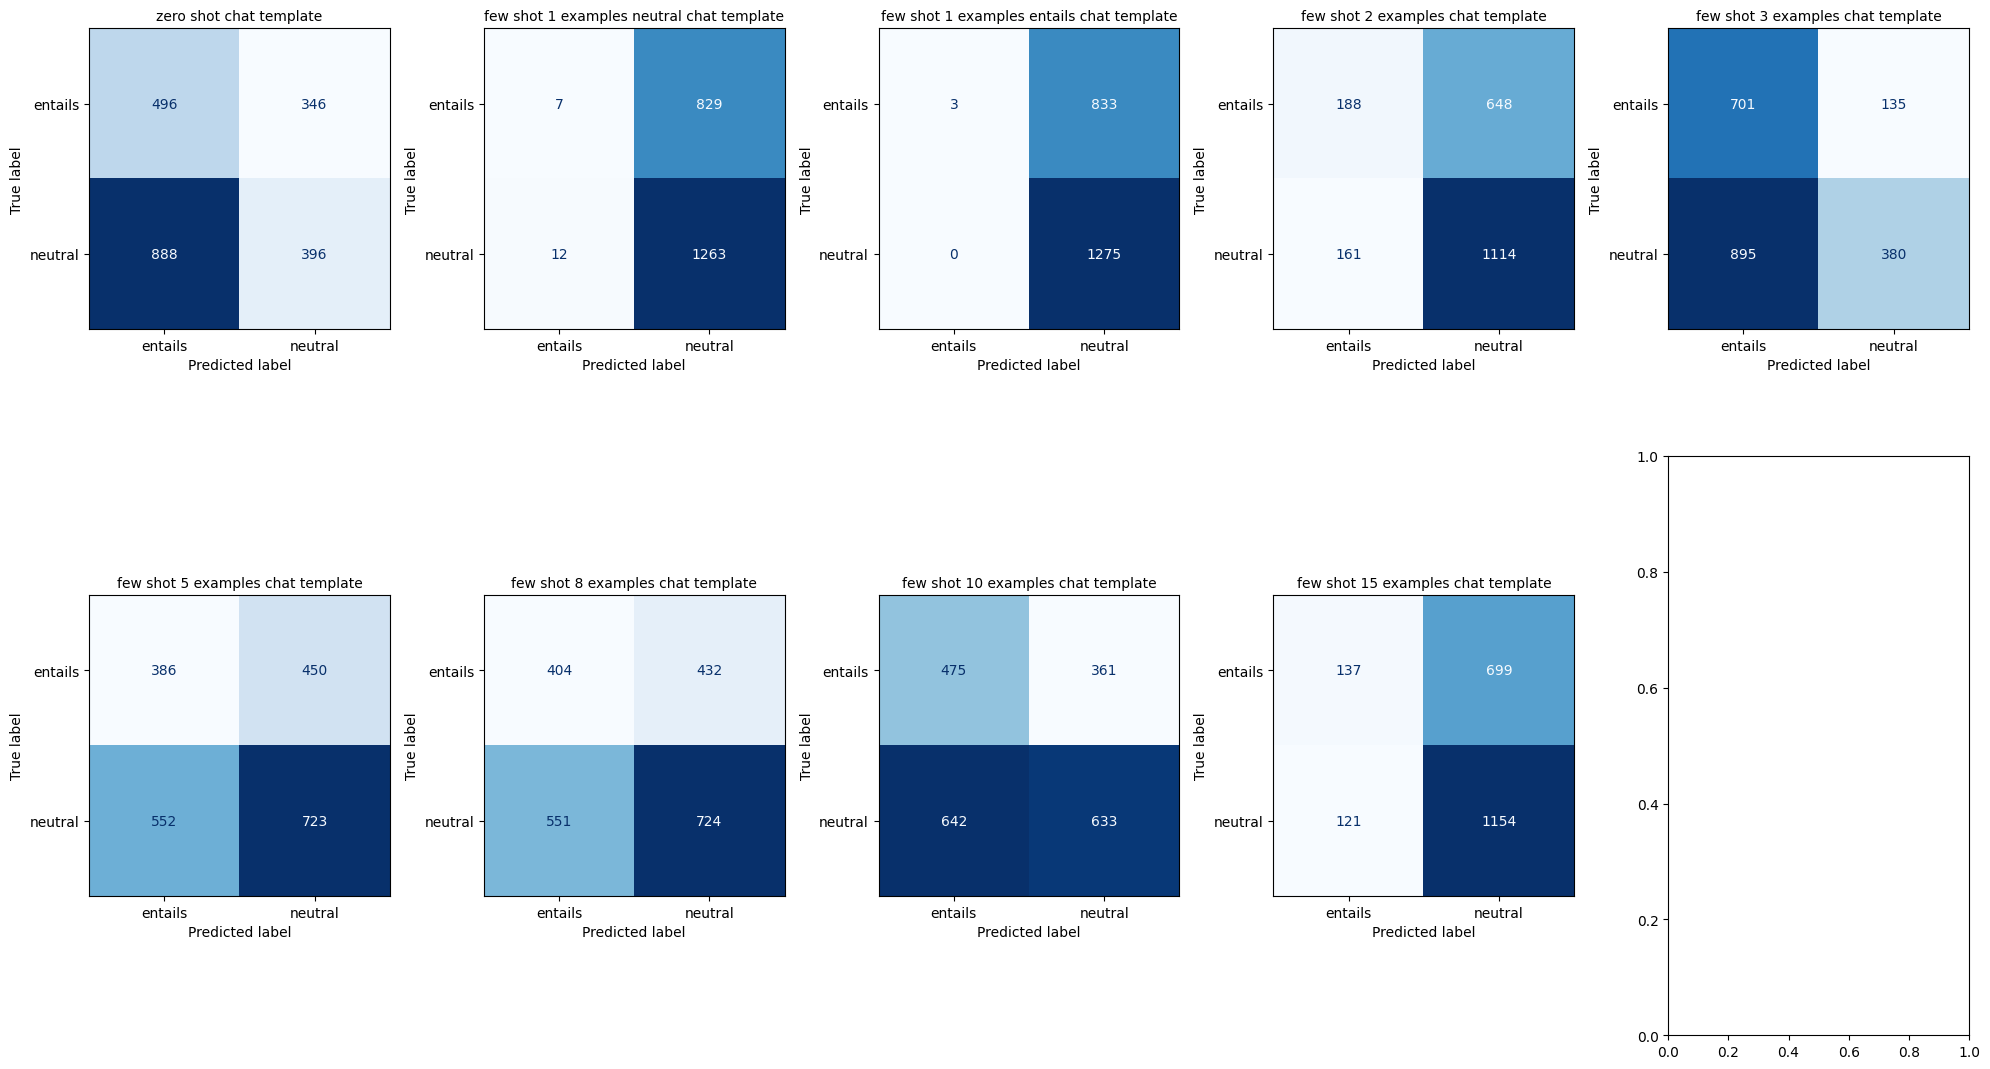

In [4]:
import matplotlib.pyplot as plt

training_modes = [
    'zero shot chat template',
    'few shot 1 examples neutral chat template',
    'few shot 1 examples entails chat template',
    'few shot 2 examples chat template',
    'few shot 3 examples chat template',
    'few shot 5 examples chat template',
    'few shot 8 examples chat template',
    'few shot 10 examples chat template',
    'few shot 15 examples chat template'    
]

fig, axes = plt.subplots(2, 5, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

for idx, mode in enumerate(training_modes):
    global_params = {
            'dataset_type': 'scitail',
            'quantization': 'full',
            'training_mode': mode,
            'model_id': 'meta-llama/Llama-3.2-3B-Instruct'}
   
    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
labels = [
    "0 examples",
    "1 example (entails)",
    "1 example (neutral)",
    "2 examples",
    "3 examples",
    "5 examples",
    "8 examples",
    "10 examples",
    "15 examples"
]

metrics_df_chat_template = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
     "F1": f1s,
     "MCC": mccs,
     "Kappa": kappas},
     index= labels
)
metrics_df_chat_template

,Accuracy,Precision,Recalls,F1,MCC,Kappa
0 examples,0.4196,0.4460,0.4487,0.4183,-0.1052,-0.0923
1 example (entails),0.6016,0.4861,0.4995,0.3833,-0.0054,-0.0012
1 example (neutral),0.6054,0.8024,0.5018,0.3805,0.0466,0.0043
2 examples,0.6168,0.5855,0.5493,0.5255,0.1298,0.1096
3 examples,0.5121,0.5885,0.5683,0.5005,0.1555,0.1181
5 examples,0.5253,0.5139,0.5144,0.5129,0.0283,0.0282
8 examples,0.5343,0.5247,0.5255,0.5234,0.0502,0.0499
10 examples,0.5249,0.5310,0.5323,0.5222,0.0633,0.0611
15 examples,0.6116,0.5769,0.5345,0.4942,0.1030,0.0783


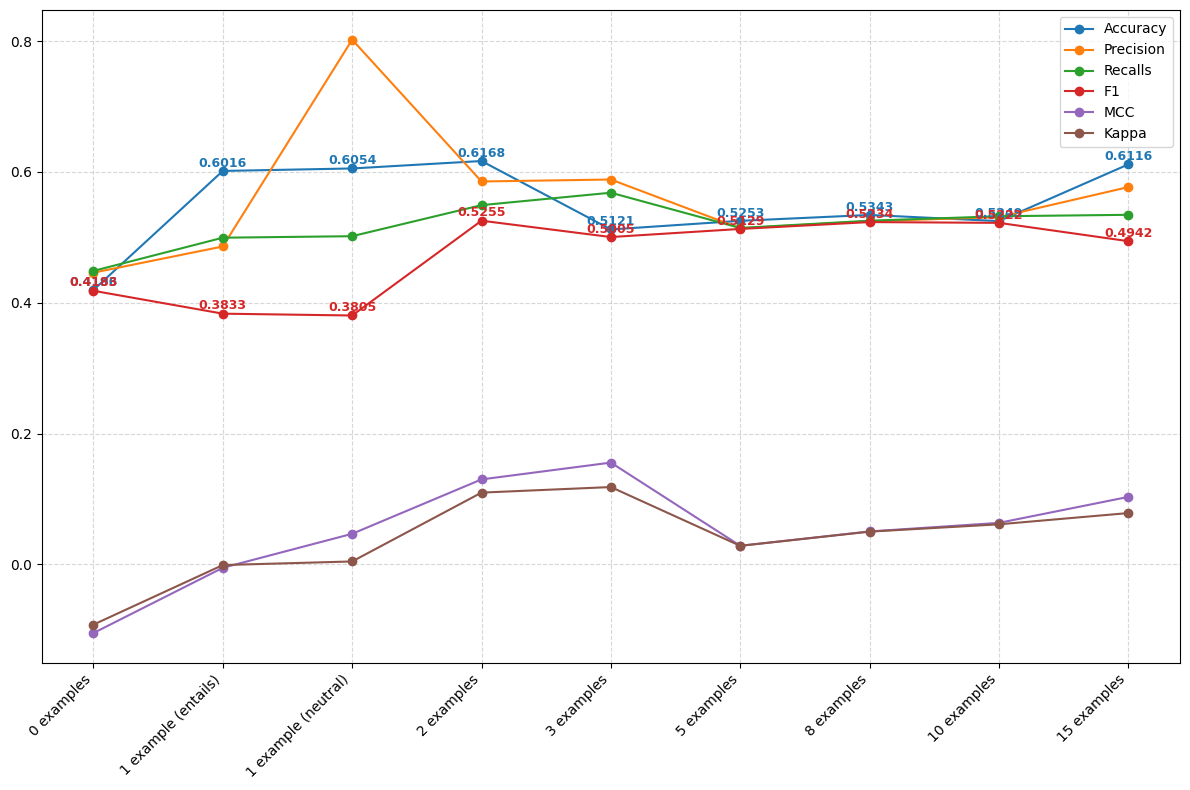

In [6]:
fig, ax = plt.subplots(figsize=(12, 8))

# plot all metrics
metrics_df_chat_template.plot(kind='line', ax=ax, marker='o')

# set custom x-axis labels
ax.set_xticks(range(len(metrics_df_chat_template.index)))
ax.set_xticklabels(metrics_df_chat_template.index, rotation=45, ha='right')

# show grid
ax.grid(True, linestyle='--', alpha=0.5)

# annotate only Accuracy and F1
for metric in ["Accuracy", "F1"]:
    for x, y in enumerate(metrics_df_chat_template[metric]):
        ax.text(x, y + 0.002, str(y), ha='center', va='bottom', fontsize=9, fontweight='bold', color=ax.get_lines()[list(metrics_df_chat_template.columns).index(metric)].get_color())

plt.tight_layout()
plt.show()